# BirdResNet Results Explorer

Loads the latest `best.pt`, evaluates train/val/test, and plots metrics + confusion analysis.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src" / "train_bird_resnet.py").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root containing src/train_bird_resnet.py")


repo_root = find_repo_root(Path.cwd())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.config import CONFIG
from src.dataset.dataloader import AugmentConfig, LoaderConfig, make_dataloaders
from src.models.bird_resnet import BirdResNet
from src.train_bird_resnet import resolve_data_dir

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_rows", 200)

repo_root

PosixPath('/Users/justyna-przy/Projects/ISE/FYP')

In [2]:
# Set this to a specific checkpoint path if you don't want auto-discovery.
CKPT_PATH: str | None = None

runs_dir = repo_root / "runs"
if CKPT_PATH is None:
    candidates = sorted(runs_dir.glob("**/best.pt"), key=lambda p: p.stat().st_mtime, reverse=True)
    if not candidates:
        raise FileNotFoundError(f"No best.pt found under {runs_dir}")
    ckpt_path = candidates[0]
else:
    ckpt_path = (repo_root / CKPT_PATH).resolve() if not Path(CKPT_PATH).is_absolute() else Path(CKPT_PATH)

data_dir = resolve_data_dir(CONFIG.paths.data_dir)
splits_dir = data_dir / "spectrograms_v1" / "splits"
train_csv = splits_dir / "train.csv"
val_csv = splits_dir / "val.csv"
test_csv = splits_dir / "test.csv"
classes_json = splits_dir / "classes.json"

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(f"Checkpoint: {ckpt_path}")
print(f"Data dir:    {data_dir}")
print(f"Device:      {device}")

Checkpoint: /Users/justyna-przy/Projects/ISE/FYP/runs/bird_resnet_v1/best.pt
Data dir:    /Users/justyna-przy/Projects/ISE/FYP/src/dataset/bird_data
Device:      mps


In [3]:
with classes_json.open("r", encoding="utf-8") as f:
    class_to_idx = json.load(f)
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}
num_classes = len(class_to_idx)

loader_cfg = LoaderConfig(batch_size=128, num_workers=0, pin_memory=False)
loaders = make_dataloaders(
    train_csv=train_csv,
    val_csv=val_csv,
    test_csv=test_csv if test_csv.exists() else None,
    classes_json=classes_json,
    loader_cfg=loader_cfg,
    aug_cfg=AugmentConfig(enable=False),
    data_dir=data_dir,
    seed=22,
)

model = BirdResNet(num_classes=num_classes)
ckpt = torch.load(ckpt_path, map_location="cpu")
state_dict = ckpt["model_state"] if isinstance(ckpt, dict) and "model_state" in ckpt else ckpt
model.load_state_dict(state_dict)
model = model.to(device).eval()

if isinstance(ckpt, dict):
    print("Checkpoint metadata:")
    for key in ["epoch", "val_f1"]:
        if key in ckpt:
            print(f"  {key}: {ckpt[key]}")

print(f"Loaded model with {num_classes} classes")

Checkpoint metadata:
  epoch: 20
  val_f1: 0.7460396113722858
Loaded model with 50 classes


In [4]:
def model_size_stats(module: torch.nn.Module) -> pd.DataFrame:
    total_params = sum(p.numel() for p in module.parameters())
    trainable_params = sum(p.numel() for p in module.parameters() if p.requires_grad)
    frozen_params = total_params - trainable_params

    param_bytes = sum(p.numel() * p.element_size() for p in module.parameters())
    buffer_bytes = sum(b.numel() * b.element_size() for b in module.buffers())

    return pd.DataFrame(
        [
            {"metric": "total_params", "value": int(total_params)},
            {"metric": "trainable_params", "value": int(trainable_params)},
            {"metric": "frozen_params", "value": int(frozen_params)},
            {"metric": "parameter_size_mb", "value": round(param_bytes / (1024 ** 2), 4)},
            {"metric": "state_size_mb_with_buffers", "value": round((param_bytes + buffer_bytes) / (1024 ** 2), 4)},
        ]
    )


model_size_stats(model)

,metric,value
0,total_params,1.243186e+06
1,trainable_params,1.243186e+06
2,frozen_params,0.000000e+00
3,parameter_size_mb,4.742400e+00
4,state_size_mb_with_buffers,4.742400e+00


In [12]:
num_classes = 51  # <-- set yours

params = sum(p.numel() for p in model.parameters())
fp32_mb = params * 4 / (1024**2)
int8_mb = params * 1 / (1024**2)

print(f"params: {params:,}")
print(f"fp32 weights ~ {fp32_mb:.2f} MiB")
print(f"int8  weights ~ {int8_mb:.2f} MiB")


params: 1,243,186
fp32 weights ~ 4.74 MiB
int8  weights ~ 1.19 MiB


In [5]:
@torch.no_grad()
def collect_predictions(model: torch.nn.Module, loader, device: torch.device):
    y_true = []
    y_pred = []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        preds = logits.argmax(dim=1).cpu().numpy()
        y_true.append(y.numpy())
        y_pred.append(preds)
    return np.concatenate(y_true), np.concatenate(y_pred)


split_metrics = {}
split_preds = {}

for split_name, loader in loaders.items():
    y_true, y_pred = collect_predictions(model, loader, device)
    split_preds[split_name] = (y_true, y_pred)
    split_metrics[split_name] = {
        "n_samples": int(len(y_true)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
    }

metrics_df = pd.DataFrame.from_dict(split_metrics, orient="index").sort_index()
metrics_df

,n_samples,accuracy,macro_f1
test,1864,0.769313,0.772815
train,14742,0.901370,0.911155
val,1829,0.733188,0.746040


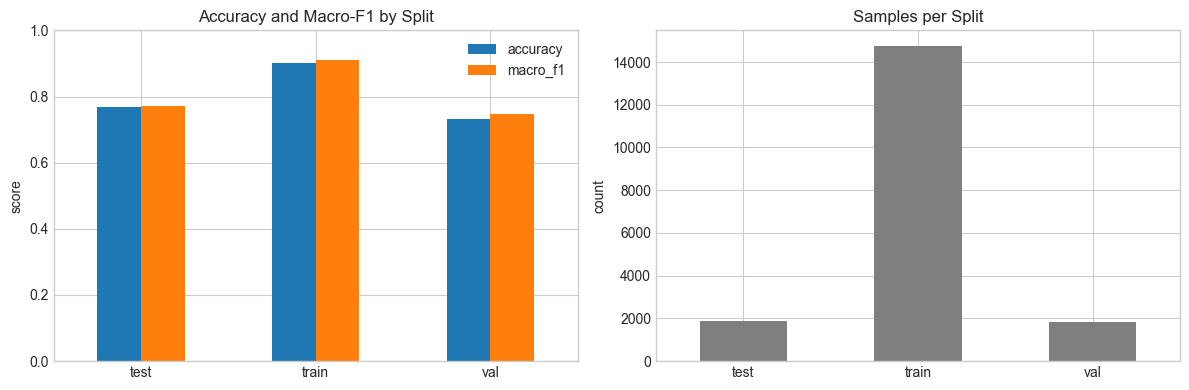

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

metrics_df[["accuracy", "macro_f1"]].plot(kind="bar", ax=axes[0], rot=0)
axes[0].set_title("Accuracy and Macro-F1 by Split")
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel("score")

metrics_df[["n_samples"]].plot(kind="bar", ax=axes[1], rot=0, legend=False, color="tab:gray")
axes[1].set_title("Samples per Split")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

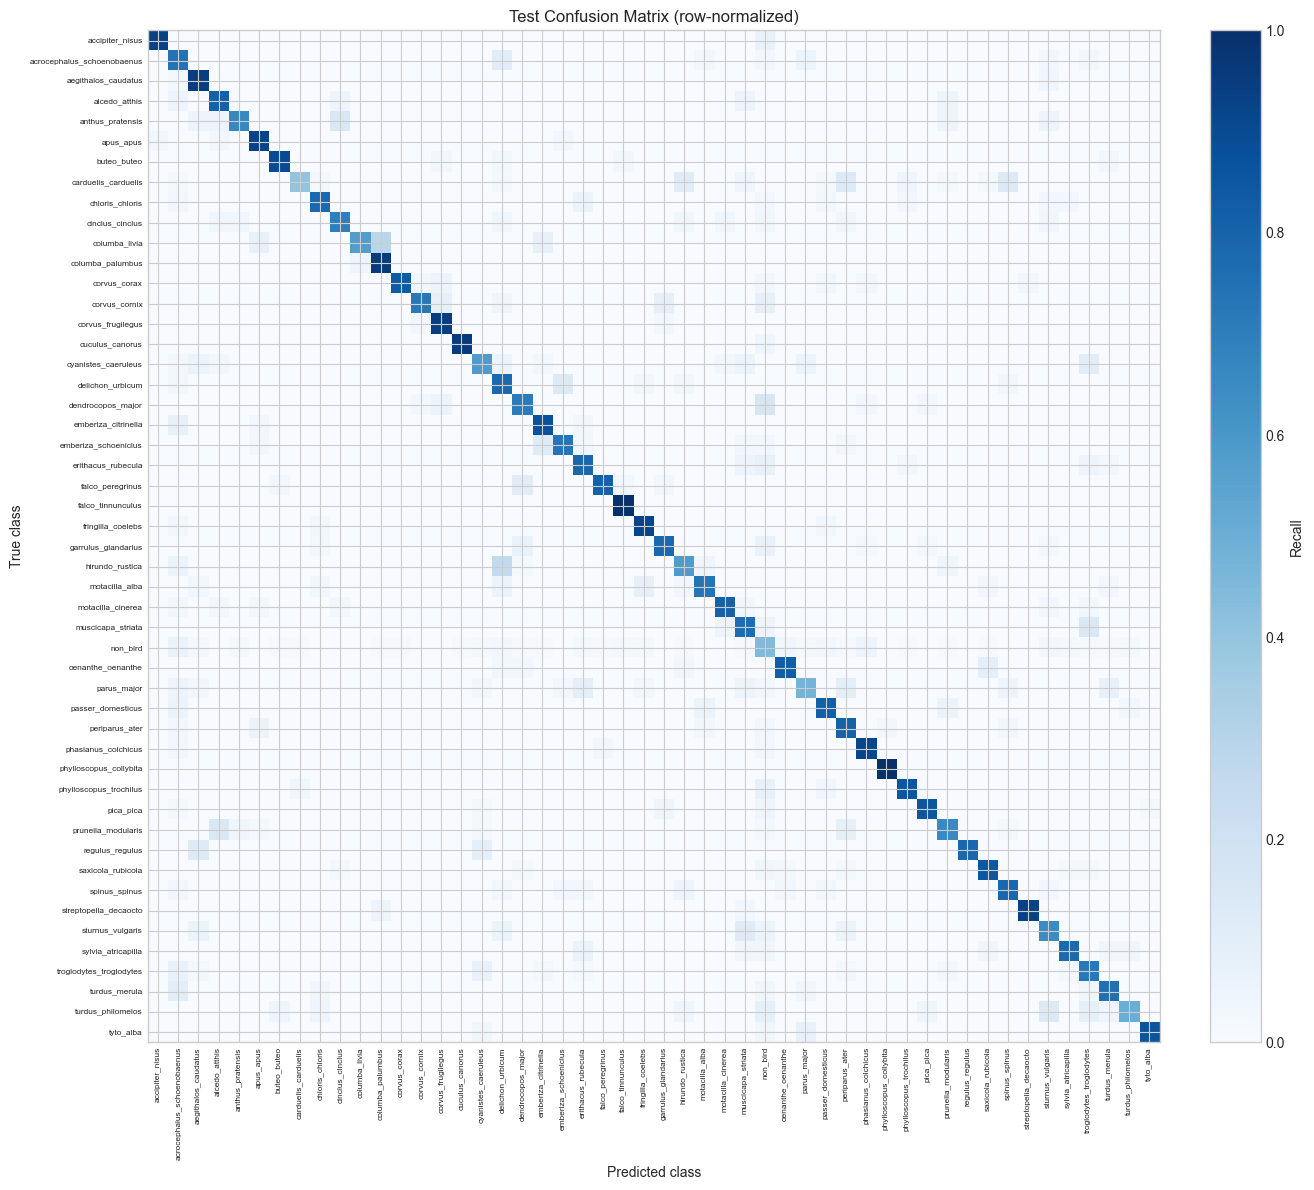

In [7]:
if "test" not in split_preds:
    raise ValueError("No test split found.")

y_true_test, y_pred_test = split_preds["test"]
labels = np.arange(num_classes)
cm_counts = confusion_matrix(y_true_test, y_pred_test, labels=labels)
cm_norm = confusion_matrix(y_true_test, y_pred_test, labels=labels, normalize="true")

tick_labels = [idx_to_class[i] for i in labels]

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm_norm, interpolation="nearest", cmap="Blues", vmin=0.0, vmax=1.0)
ax.set_title("Test Confusion Matrix (row-normalized)")
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_xticks(labels)
ax.set_yticks(labels)
ax.set_xticklabels(tick_labels, rotation=90, fontsize=6)
ax.set_yticklabels(tick_labels, fontsize=6)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Recall")
plt.tight_layout()
plt.show()

In [8]:
cm_no_diag = cm_counts.copy()
np.fill_diagonal(cm_no_diag, 0)

top_k = 20
flat_idx = np.argsort(cm_no_diag, axis=None)[::-1]
rows, cols = np.unravel_index(flat_idx[:top_k], cm_no_diag.shape)

top_confusions = []
for r, c in zip(rows, cols):
    count = int(cm_no_diag[r, c])
    if count <= 0:
        continue
    top_confusions.append({
        "true_class": idx_to_class[r],
        "pred_class": idx_to_class[c],
        "count": count,
    })

top_confusions_df = pd.DataFrame(top_confusions)
top_confusions_df

,true_class,pred_class,count
0,hirundo_rustica,delichon_urbicum,13
1,prunella_modularis,alcedo_atthis,7
2,non_bird,acrocephalus_schoenobaenus,7
3,carduelis_carduelis,periparus_ater,6
4,dendrocopos_major,non_bird,6
5,carduelis_carduelis,spinus_spinus,6
6,delichon_urbicum,emberiza_schoeniclus,5
7,non_bird,phasianus_colchicus,5
8,carduelis_carduelis,hirundo_rustica,5
9,cyanistes_caeruleus,troglodytes_troglodytes,4


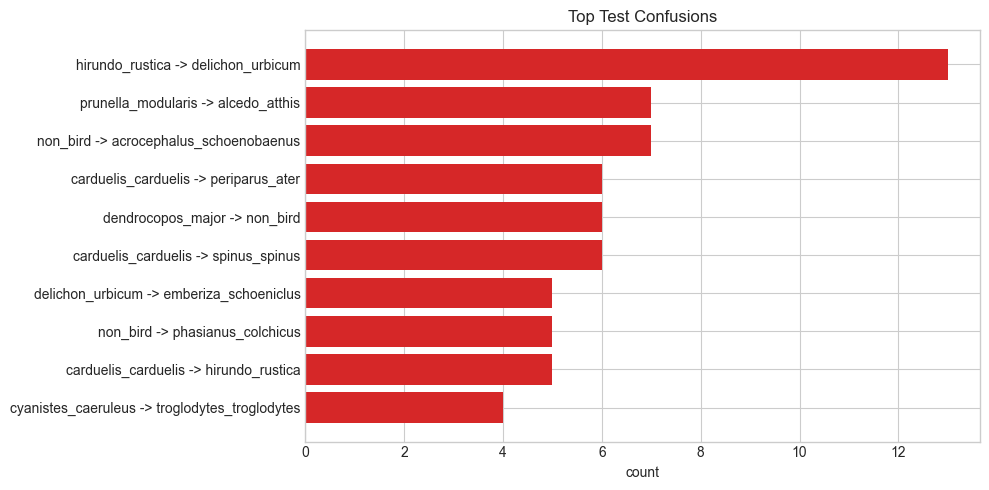

In [9]:
if not top_confusions_df.empty:
    plot_df = top_confusions_df.head(10).copy()
    plot_df["pair"] = plot_df["true_class"] + " -> " + plot_df["pred_class"]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(plot_df["pair"][::-1], plot_df["count"][::-1], color="tab:red")
    ax.set_title("Top Test Confusions")
    ax.set_xlabel("count")
    plt.tight_layout()
    plt.show()
else:
    print("No off-diagonal confusions found.")